## **TUGAS**

In [1]:
pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv('data250.csv')
df = df[['content']]
print(df.head())

                                             content
0  saya dulu main dari sampai dan ternyata free f...
1  aku suka banget main nya seru kalo aku gabut a...
2                                      minta ff beta
3                                        sangat seru
4          semakin kesini semakin pelit hoki dia ini


In [7]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

try:
    stop_word = set(stopwords.words('indonesian'))
except:
    stop_word = set([
    "yang","dan","di","ke","dari","ini","itu","atau","jadi","karena","agar",
    "sudah","udah","belum","lagi","aja","saja","banget","sangat","sekali",
    "nya","aku","saya","kami","kita","dia","mereka","kamu","min","bang","bg",
    "loh","lah","kok","yaa","yah","deh","nih","dong","pls","pliss",
    "main","bermain","pake","pakai","bikin","buat","jadi","punya","dapet",
    "dapat","kasih","minta","tolong","ngasih","bilang","bagi",
    "bagus","jelek","burik","seru","keren","mantap","asik","buruk","lumayan",
    "parah","rusak","seneng","sedih","kecewa","suka","benci",
    "game","ff","free","fire","garena","rank","ranked","cs","push","season",
    "update","event","map","top","up","diamond","gem","skin","bundle",
    "login","loading","download","akun","server","jaringan",
    "anj","anjir","njir","woi","woy","lol","haha","hehe","wkwk","kwkw",
    "ok","oke","sip","yah","ya","tidak","ada","ulasan"])

def preprocessing(content):
    content = re.sub(r'[^a-zA-Z\s]', '', content.lower())
    tokens = content.split()
    filtered_tokens = [token for token in tokens if token not in stop_word]
    stemmed = [stemmer.stem(token) for token in filtered_tokens]
    return ' '.join(stemmed)

df['stemmed'] = df['content'].apply(preprocessing)
df[['stemmed']].to_csv('hasil_preprocessing.csv', index=False)

In [8]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['stemmed'])
import pandas as pd

# Ambil fitur dan tampilkan sebagian
df_tfidf = pd.DataFrame(X.toarray(), columns=tfidf.get_feature_names_out())
df_tfidf.head(5).iloc[:, :5]


,abis,abnormal,adakan,adil,aduh
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0


In [9]:
range_n_clusters = range(2, 8)
scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    scores.append(silhouette_score(X, kmeans.labels_))

In [14]:
best_k = list(range_n_clusters)[np.argmax(scores)]
print(f'K optimal berdasarkan Silhouette Score: {best_k}')

K optimal berdasarkan Silhouette Score: 5


In [15]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)


In [17]:
kmeans= KMeans(n_clusters=5, random_state=42,n_init=10)
kmeans.fit(X)

KMeans(n_clusters=5, n_init=10, random_state=42)

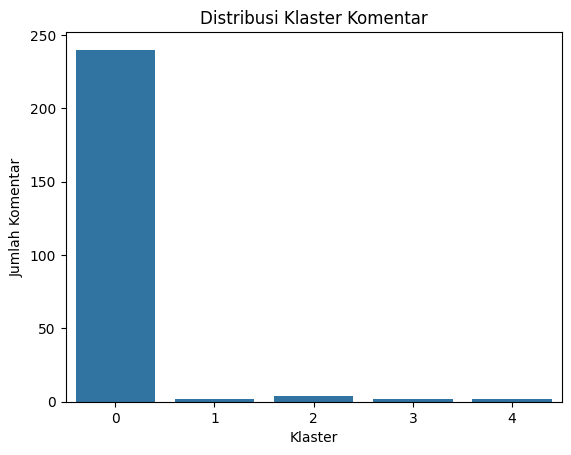

In [18]:
sns.countplot(x='cluster', data=df)
plt.title('Distribusi Klaster Komentar')
plt.xlabel('Klaster')
plt.ylabel('Jumlah Komentar')
plt.show()

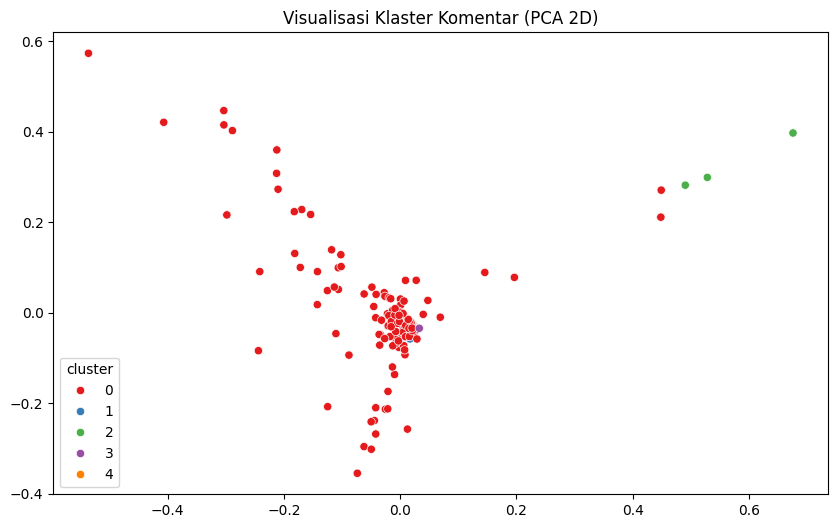

In [19]:
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X.toarray())
plt.figure(figsize=(10,6))
sns.scatterplot(x=reduced_data[:,0], y=reduced_data[:,1], hue=df['cluster'], palette='Set1')
plt.title('Visualisasi Klaster Komentar (PCA 2D)')
plt.show()

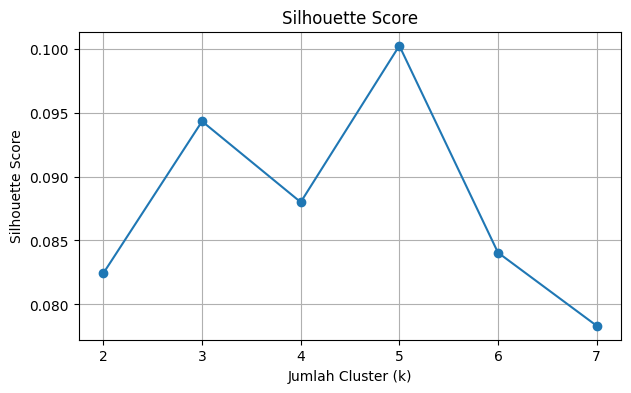

In [20]:
plt.figure(figsize=(7,4))
plt.plot(range_n_clusters, scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [21]:
final_score = silhouette_score(X, df['cluster'])
print(f'Silhouette Score (k={best_k}): {final_score:.4f}')

Silhouette Score (k=5): 0.1002


ELBOW

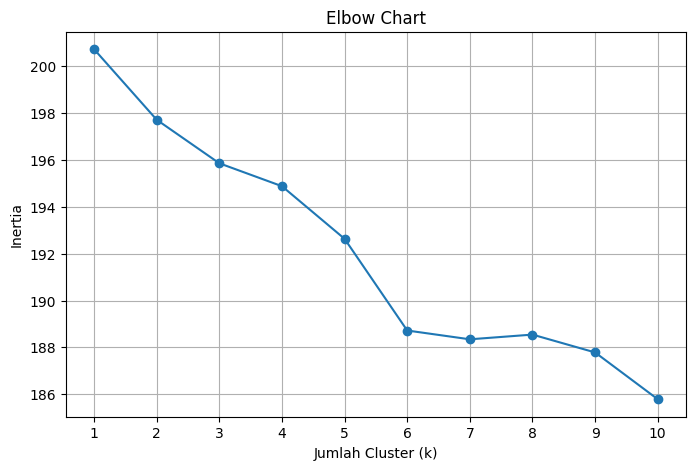

K optimal (Elbow) = 6
Inertia pada K optimal = 188.71900997166253


In [22]:
inertia_values = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

# --- 2. Plot Elbow ---
plt.figure(figsize=(8,5))
plt.plot(K, inertia_values, marker='o')
plt.title("Elbow Chart")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.xticks(K)
plt.grid(True)
plt.show()

#Metode Jarak ke Garis (Menentukan Elbow)
x1, y1 = 1, inertia_values[0]      # titik pertama
x2, y2 = K[-1], inertia_values[-1] # titik terakhir

distances = []
for k, inertia in zip(K, inertia_values):
    # rumus jarak titik ke garis
    distance = abs((y2 - y1)*k - (x2 - x1)*inertia + x2*y1 - y2*x1) / np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
    distances.append(distance)

optimal_k = K[np.argmax(distances)]
optimal_inertia = inertia_values[optimal_k - 1]

print("K optimal (Elbow) =", optimal_k)
print("Inertia pada K optimal =", optimal_inertia)